## Cleveland Heart Disease Data

Classic dataset from the UCI Machine Learning Repository. Predicts presence of heart disease from clinical attributes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
%matplotlib inline

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
df = pd.read_csv(url, names=columns, na_values='?')
df_raw = df.copy()

print(f'Shape: {df.shape}')
df.head()

## Exploratory Data Analysis

In [ ]:
print('--- Dtypes ---')
print(df.dtypes)

print('\n--- Missing Values ---')
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

print('\n--- Duplicates ---')
print(f'Duplicate rows: {df.duplicated().sum()}')

In [ ]:
df.describe().T.style.background_gradient(cmap='Blues', axis=0)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = df['target'].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Target Distribution (0–4)')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

binary = (df['target'] > 0).astype(int)
bc = binary.value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
axes[1].bar(['No Disease (0)', 'Disease (1)'], bc.values, color=colors, edgecolor='white')
axes[1].set_title('Binary Target (0 vs 1+)')
for i, v in enumerate(bc.values):
    axes[1].text(i, v + 0.5, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
df_binary = df.copy()
df_binary['target'] = (df_binary['target'] > 0).astype(int)

plt.figure(figsize=(12, 9))
corr = df_binary.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
target_corr = df_binary.corr()['target'].drop('target').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.set_title('Correlation with Target (binary)', fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(target_corr.values):
    ax.text(v + 0.01 if v > 0 else v - 0.06, i, f'{v:.2f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    for label, color, name in [(0, '#2ecc71', 'No Disease'), (1, '#e74c3c', 'Disease')]:
        subset = df_binary[df_binary['target'] == label][feat].dropna()
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=name, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)

axes[5].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
print(f'Rows before dropping NaN: {len(df_raw)}')
df.dropna(inplace=True)
print(f'Rows after dropping NaN:  {len(df)}')
print(f'Lost: {len(df_raw) - len(df)} rows')

## Decisions

In [ ]:
X = df.drop('target', axis=1)
y = (df['target'] > 0).astype(int)

print(f'X shape: {X.shape}')
print(f'y distribution:\n{y.value_counts()}')

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train class balance:\n{y_train.value_counts(normalize=True)}')
print(f'Test class balance:\n{y_test.value_counts(normalize=True)}')

## Baseline Model

Simulating a person guessing: coin flip vs. guessing based on class proportions.

| Strategy | What a person does | Expected accuracy |
|----------|--------------------|-------------------|
| Coin flip | Flips a coin per patient — 50% disease, 50% no disease | ~50% |
| Stratified guess | Knows ~46% have disease, so guesses "disease" 46% of the time — still random per patient | ~54% (trivially, by favoring the majority class) |
| Majority class | Predicts "no disease" for everyone — always bets on the most common outcome | ~54% |

Any real model must beat both.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rng = np.random.default_rng(42)

results = {'coin_flip': {'acc': [], 'conf': []},
           'stratified': {'acc': [], 'conf': []},
           'majority': {'acc': [], 'conf': []}}

for train_idx, val_idx in cv.split(X_train, y_train):
    y_val = y_train.iloc[val_idx].values
    n = len(y_val)

    y_pred_coin = rng.integers(0, 2, n)
    results['coin_flip']['acc'].append(accuracy_score(y_val, y_pred_coin))
    results['coin_flip']['conf'].append(confusion_matrix(y_val, y_pred_coin))

    p = y_train.iloc[train_idx].mean()
    y_pred_strat = (rng.random(n) < p).astype(int)
    results['stratified']['acc'].append(accuracy_score(y_val, y_pred_strat))
    results['stratified']['conf'].append(confusion_matrix(y_val, y_pred_strat))

    y_pred_maj = np.zeros(n, dtype=int)
    results['majority']['acc'].append(accuracy_score(y_val, y_pred_maj))
    results['majority']['conf'].append(confusion_matrix(y_val, y_pred_maj))

for name in ['coin_flip', 'stratified', 'majority']:
    accs = results[name]['acc']
    print(f'{name}: accuracy = {np.mean(accs):.3f} ± {np.std(accs):.3f}')

fig, ax = plt.subplots(figsize=(8, 5))
baseline_names = ['Coin Flip', 'Stratified', 'Majority']
ax.boxplot([results['coin_flip']['acc'], results['stratified']['acc'], results['majority']['acc']], tick_labels=baseline_names)
for i, name in enumerate(['coin_flip', 'stratified', 'majority']):
    ax.scatter([i + 1] * len(results[name]['acc']), results[name]['acc'], s=60, zorder=3)
ax.set_ylabel('Accuracy')
ax.set_title('Human Guessing Baseline (5-fold CV)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, ['coin_flip', 'stratified', 'majority']):
    avg_conf = np.mean(results[name]['conf'], axis=0)
    sns.heatmap(avg_conf, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
    ax.set_title(name.replace('_', ' ').title())
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## MLP Cross-Validation

5-fold stratified CV on the 237-sample training set. Scaler is fit **per fold on the training split only** to prevent data leakage. Same CV splits as the baselines for a fair comparison.

In [75]:
# ============================================================
# Hyperparameters — adjust these to tune the model
# ============================================================
HIDDEN_LAYERS = [64, 32]        # hidden layer widths
DROPOUT       = 0.4             # dropout probability
LR            = 0.001            # learning rate
WEIGHT_DECAY  = 1e-4            # L2 regularization
EPOCHS        = 60             # training epochs

# ============================================================
# Model
# ============================================================
class HeartMLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers.extend([
                nn.Linear(prev, h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# ============================================================
# Training helpers
# ============================================================
def train_epoch(model, X, y, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    logits = model(X).squeeze()
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, X, y, criterion):
    model.eval()
    logits = model(X).squeeze()
    loss = criterion(logits, y).item()
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).int()
    acc = (preds == y).float().mean().item()
    return loss, acc, probs.cpu().numpy(), preds.cpu().numpy()

In [76]:
orig_fold = {
    'train_losses': [],
    'val_losses':   [],
    'val_acc':      [],
    'val_preds':    [],
    'val_y':        [],
}

X_np = X_train.values.astype(np.float32)
y_np = y_train.values.astype(np.float32)

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_np, y_np)):
    print(f'Fold {fold+1}/{cv.n_splits} ... ', end='', flush=True)

    X_tr, X_val = X_np[tr_idx], X_np[val_idx]
    y_tr, y_val = y_np[tr_idx], y_np[val_idx]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)

    X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_val_t = torch.tensor(X_val_s, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32)

    model = HeartMLP(X_tr_t.shape[1], HIDDEN_LAYERS, DROPOUT)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.BCEWithLogitsLoss()

    tr_losses, vl_losses = [], []
    for epoch in range(EPOCHS):
        tr_l = train_epoch(model, X_tr_t, y_tr_t, optimizer, criterion)
        vl_l, vl_a, _, _ = evaluate(model, X_val_t, y_val_t, criterion)
        tr_losses.append(tr_l)
        vl_losses.append(vl_l)

    _, final_acc, _, final_preds = evaluate(model, X_val_t, y_val_t, criterion)

    orig_fold['train_losses'].append(tr_losses)
    orig_fold['val_losses'].append(vl_losses)
    orig_fold['val_acc'].append(final_acc)
    orig_fold['val_preds'].append(final_preds)
    orig_fold['val_y'].append(y_val)

    print(f'Val Acc: {final_acc:.4f}')

orig_accs = np.array(orig_fold['val_acc'])
orig_all_preds = np.concatenate(orig_fold['val_preds'])
orig_all_y = np.concatenate(orig_fold['val_y'])

print(f'\nOriginal MLP CV Accuracy: {orig_accs.mean():.4f} ± {orig_accs.std():.4f}')

Fold 1/5 ... Val Acc: 0.8958
Fold 2/5 ... Val Acc: 0.7708
Fold 3/5 ... Val Acc: 0.7234
Fold 4/5 ... Val Acc: 0.9149
Fold 5/5 ... Val Acc: 0.8085

Original MLP CV Accuracy: 0.8227 ± 0.0729


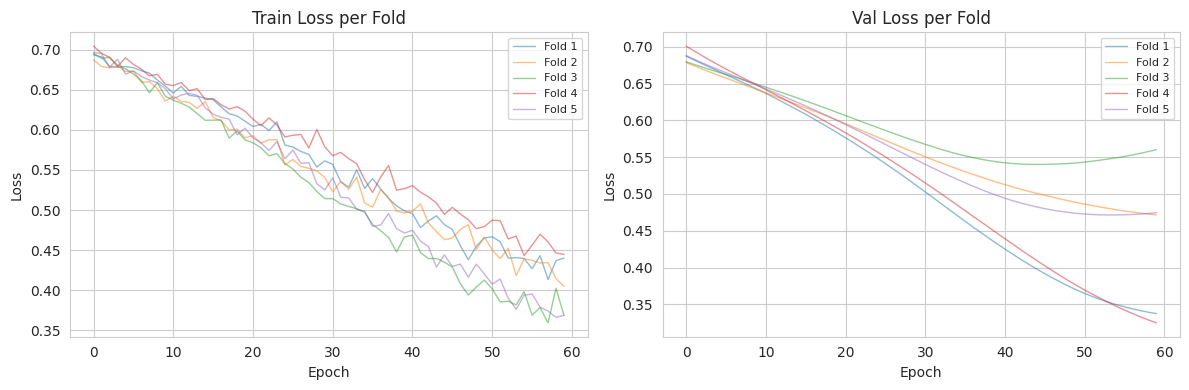

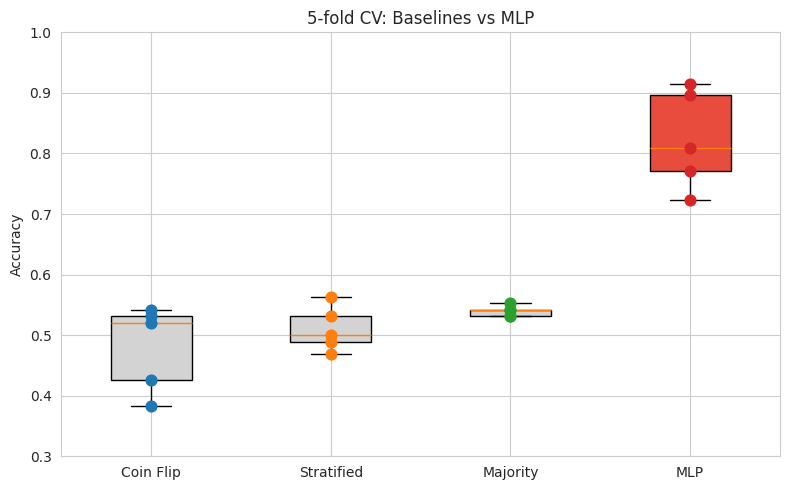

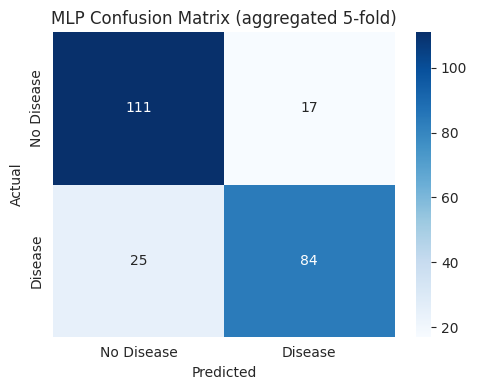

In [77]:
# ---- Loss curves ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(cv.n_splits):
    axes[0].plot(orig_fold['train_losses'][i], alpha=0.5, lw=1, label=f'Fold {i+1}')
    axes[1].plot(orig_fold['val_losses'][i],   alpha=0.5, lw=1, label=f'Fold {i+1}')
axes[0].set_title('Train Loss per Fold')
axes[1].set_title('Val Loss per Fold')
for ax in axes:
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ---- Accuracy comparison ----
fig, ax = plt.subplots(figsize=(8, 5))
to_plot = [results['coin_flip']['acc'], results['stratified']['acc'],
           results['majority']['acc'], orig_accs]
labs = ['Coin Flip', 'Stratified', 'Majority', 'MLP']
cols = ['#d3d3d3', '#d3d3d3', '#d3d3d3', '#e74c3c']
bp = ax.boxplot(to_plot, tick_labels=labs, patch_artist=True)
for patch, c in zip(bp['boxes'], cols):
    patch.set_facecolor(c)
for i in range(4):
    ax.scatter([i+1]*len(to_plot[i]), to_plot[i], s=60, zorder=3)
ax.set_ylabel('Accuracy'); ax.set_ylim(0.3, 1.0)
ax.set_title('5-fold CV: Baselines vs MLP')
plt.tight_layout(); plt.show()

# ---- Confusion matrix ----
conf = confusion_matrix(orig_all_y, orig_all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
ax.set_title('MLP Confusion Matrix (aggregated 5-fold)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## MLP — Early Stopping + ROC-AUC

Same 5-fold splits as above. Key differences:
- **Early stopping**: restores best weights (by val loss) instead of using epoch 300
- **ReduceLROnPlateau**: halves LR when val loss plateaus
- **ROC-AUC** metric instead of accuracy
- **Per-fold class distribution** printed for transparency

In [93]:
from sklearn.metrics import roc_auc_score

# ============================================================
# Hyperparameters (early-stop version)
# ============================================================
HIDDEN_LAYERS = [64, 32]        # hidden layer widths
DROPOUT       = 0.2             # dropout probability
LR            = 0.001            # learning rate
WEIGHT_DECAY  = 1e-4            # L2 regularization
EPOCHS        = 300             # max training epochs per fold
PATIENCE      = 60              # early stopping patience (val loss)
LR_FACTOR     = 0.5             # ReduceLROnPlateau factor

# Model (identical to original)
class HeartMLP_ES(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers.extend([
                nn.Linear(prev, h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Training helpers (identical to original)
def train_epoch_es(model, X, y, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    logits = model(X).squeeze()
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate_es(model, X, y, criterion):
    model.eval()
    logits = model(X).squeeze()
    loss = criterion(logits, y).item()
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).int()
    acc = (preds == y).float().mean().item()
    return loss, acc, probs.cpu().numpy(), preds.cpu().numpy()

In [94]:
es_fold = {
    'val_acc':      [],
    'val_auc':      [],
    'val_probs':    [],
    'val_preds':    [],
    'val_y':        [],
    'stopped_at':   [],
}

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_np, y_np)):
    print(f'Fold {fold+1}/{cv.n_splits} ... ', end='', flush=True)

    X_tr, X_val = X_np[tr_idx], X_np[val_idx]
    y_tr, y_val = y_np[tr_idx], y_np[val_idx]

    n0_tr = int((y_tr == 0).sum())
    n1_tr = int((y_tr == 1).sum())
    n0_val = int((y_val == 0).sum())
    n1_val = int((y_val == 1).sum())
    print(f'Train: 0={n0_tr} 1={n1_tr} | Val: 0={n0_val} 1={n1_val}')

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)

    X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_val_t = torch.tensor(X_val_s, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32)

    model = HeartMLP_ES(X_tr_t.shape[1], HIDDEN_LAYERS, DROPOUT)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.BCEWithLogitsLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=LR_FACTOR, patience=PATIENCE // 2
    )

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    stopped = EPOCHS

    for epoch in range(EPOCHS):
        tr_l = train_epoch_es(model, X_tr_t, y_tr_t, optimizer, criterion)
        vl_l, vl_a, _, _ = evaluate_es(model, X_val_t, y_val_t, criterion)
        scheduler.step(vl_l)

        if vl_l < best_val_loss:
            best_val_loss = vl_l
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            stopped = epoch + 1
            print(f'(stopped epoch {stopped}) ', end='', flush=True)
            break

    model.load_state_dict(best_state)
    _, final_acc, final_probs, final_preds = evaluate_es(model, X_val_t, y_val_t, criterion)
    final_auc = roc_auc_score(y_val, final_probs)

    es_fold['val_acc'].append(final_acc)
    es_fold['val_auc'].append(final_auc)
    es_fold['val_probs'].append(final_probs)
    es_fold['val_preds'].append(final_preds)
    es_fold['val_y'].append(y_val)
    es_fold['stopped_at'].append(stopped)

    print(f'    AUC: {final_auc:.4f} | Acc: {final_acc:.4f}')

es_aucs = np.array(es_fold['val_auc'])
es_all_preds = np.concatenate(es_fold['val_preds'])
es_all_probs = np.concatenate(es_fold['val_probs'])
es_all_y = np.concatenate(es_fold['val_y'])

print(f'\nEarly-Stop MLP CV ROC-AUC: {es_aucs.mean():.4f} ± {es_aucs.std():.4f}')

Fold 1/5 ... Train: 0=102 1=87 | Val: 0=26 1=22
(stopped epoch 131)     AUC: 0.9231 | Acc: 0.8958
Fold 2/5 ... Train: 0=102 1=87 | Val: 0=26 1=22
(stopped epoch 114)     AUC: 0.8601 | Acc: 0.7917
Fold 3/5 ... Train: 0=103 1=87 | Val: 0=25 1=22
(stopped epoch 104)     AUC: 0.7709 | Acc: 0.7234
Fold 4/5 ... Train: 0=103 1=87 | Val: 0=25 1=22
(stopped epoch 251)     AUC: 0.9545 | Acc: 0.8723
Fold 5/5 ... Train: 0=102 1=88 | Val: 0=26 1=21
(stopped epoch 114)     AUC: 0.8333 | Acc: 0.8085

Early-Stop MLP CV ROC-AUC: 0.8684 ± 0.0651


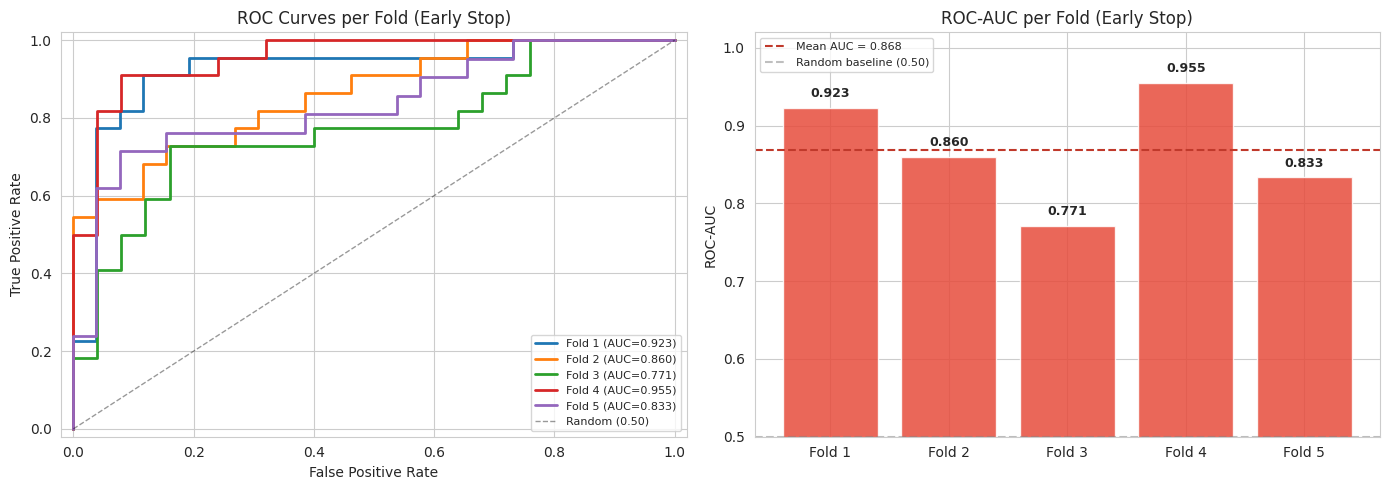

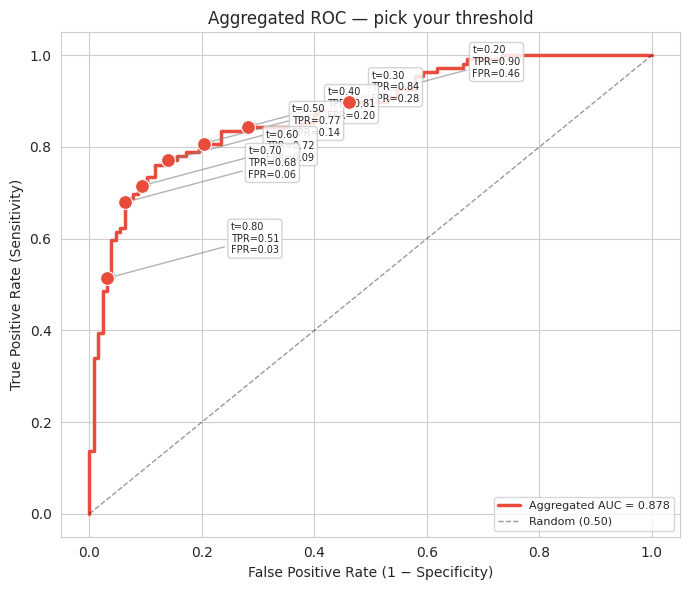

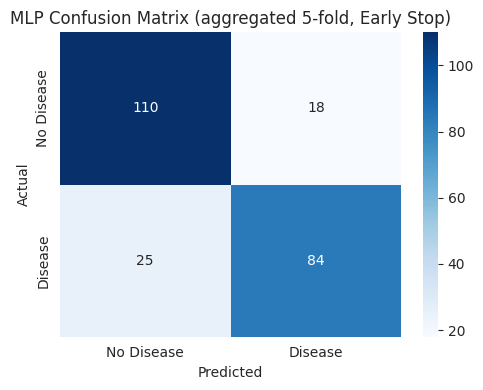

Original:        Acc = 0.8227 ± 0.0729
Early Stop:   ROC-AUC = 0.8684 ± 0.0651
               Acc = 0.8184 ± 0.0612
Stopped at epochs: [131, 114, 104, 251, 114]


In [97]:
from sklearn.metrics import roc_curve

# ---- ROC curves per fold ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i in range(cv.n_splits):
    fpr, tpr, _ = roc_curve(es_fold['val_y'][i], es_fold['val_probs'][i])
    ax1.plot(fpr, tpr, lw=2, label=f'Fold {i+1} (AUC={es_fold["val_auc"][i]:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random (0.50)')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves per Fold (Early Stop)')
ax1.legend(fontsize=8, loc='lower right')
ax1.set_xlim([-0.02, 1.02]); ax1.set_ylim([-0.02, 1.02])

# ---- ROC-AUC bar chart ----
folds = [f'Fold {i+1}' for i in range(cv.n_splits)]
bars = ax2.bar(folds, es_aucs, color='#e74c3c', edgecolor='white', alpha=0.85)
ax2.axhline(y=es_aucs.mean(), color='#c0392b', ls='--', lw=1.5,
            label=f'Mean AUC = {es_aucs.mean():.3f}')
ax2.axhline(y=0.50, color='gray', ls='--', lw=1.5, alpha=0.5,
            label='Random baseline (0.50)')
for bar, auc in zip(bars, es_aucs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{auc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax2.set_ylabel('ROC-AUC'); ax2.set_ylim(0.5, 1.02)
ax2.set_title('ROC-AUC per Fold (Early Stop)')
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ---- Aggregated ROC with threshold annotations ----
fpr_agg, tpr_agg, thresh_agg = roc_curve(es_all_y, es_all_probs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_agg, tpr_agg, lw=2.5, color='#e74c3c',
        label=f'Aggregated AUC = {roc_auc_score(es_all_y, es_all_probs):.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random (0.50)')

for t_target in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    idx = np.argmin(np.abs(thresh_agg - t_target))
    ax.scatter(fpr_agg[idx], tpr_agg[idx], s=100, zorder=5,
               color='#e74c3c', edgecolors='white', linewidths=0.8)
    ax.annotate(f't={t_target:.2f}\nTPR={tpr_agg[idx]:.2f}\nFPR={fpr_agg[idx]:.2f}',
                xy=(fpr_agg[idx], tpr_agg[idx]),
                xytext=(fpr_agg[idx] + 0.22, tpr_agg[idx] + 0.05),
                fontsize=7, va='bottom', ha='left',
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.6),
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85,
                          ec='#ccc'))

ax.set_xlabel('False Positive Rate (1 − Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('Aggregated ROC — pick your threshold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

# ---- Confusion matrix (aggregated) ----
conf = confusion_matrix(es_all_y, es_all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
ax.set_title('MLP Confusion Matrix (aggregated 5-fold, Early Stop)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

# ---- Summary comparison ----
print('=' * 50)
print(f'Original:        Acc = {orig_accs.mean():.4f} ± {orig_accs.std():.4f}')
print(f'Early Stop:   ROC-AUC = {es_aucs.mean():.4f} ± {es_aucs.std():.4f}')
print(f'               Acc = {np.array(es_fold["val_acc"]).mean():.4f} ± {np.array(es_fold["val_acc"]).std():.4f}')
print(f'Stopped at epochs: {es_fold["stopped_at"]}')
print('=' * 50)

## Threshold Matrix

Same aggregated predictions (`es_all_y` / `es_all_probs`) evaluated at 7 different probability cutoffs. Scan left-to-right: lower thresholds catch more disease (higher TPR) at the cost of more false alarms (higher FPR).

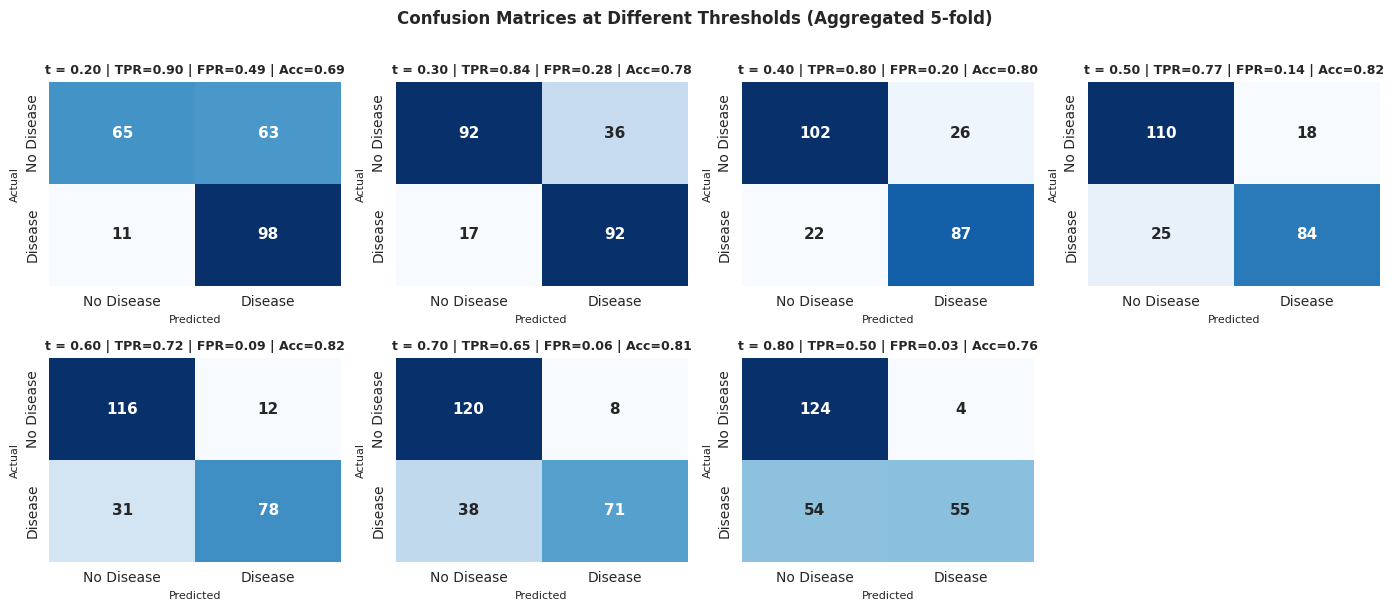

In [98]:
# --- Threshold grid ---
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
n = len(thresholds)
n_cols = 4
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3 * n_rows))
axes = axes.flatten()

for ax, t in zip(axes, thresholds):
    preds_t = (es_all_probs > t).astype(int)
    cm = confusion_matrix(es_all_y, preds_t)
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    acc = (tp + tn) / cm.sum()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                cbar=False, annot_kws={'fontsize': 11, 'fontweight': 'bold'},
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    ax.set_title(f't = {t:.2f} | TPR={tpr:.2f} | FPR={fpr:.2f} | Acc={acc:.2f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)

# Hide unused subplots
for ax in axes[n:]:
    ax.axis('off')

plt.suptitle('Confusion Matrices at Different Thresholds (Aggregated 5-fold)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Final Model — Holdout Test Evaluation

Train on **all 237 samples** for 150 epochs (guided by CV: mean stop=143, range 104–251). No early stopping since we have no validation split — the 60 held-out test patients serve as the true validator. Uses the same architecture and hyperparameters as the early-stop CV pipeline.

Decision threshold:       t = 0.5
CV ROC-AUC (mean ± std):  0.8684 ± 0.0651
Test ROC-AUC:              0.9353
Test Accuracy:             0.8333


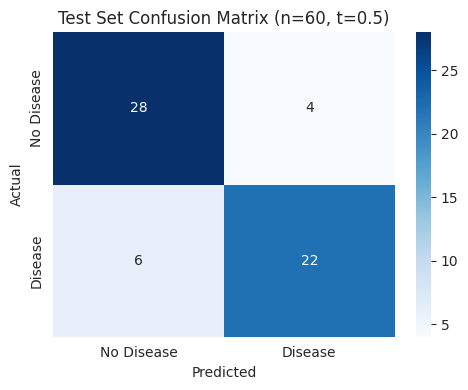

In [104]:
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train.values.astype(np.float32))
X_test_scaled  = scaler_final.transform(X_test.values.astype(np.float32))

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values.astype(np.float32))
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values.astype(np.float32))

model_final = HeartMLP_ES(X_train_t.shape[1], HIDDEN_LAYERS, DROPOUT)
optimizer = optim.Adam(model_final.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(150):
    train_epoch_es(model_final, X_train_t, y_train_t, optimizer, criterion)

_, _, test_probs, _ = evaluate_es(model_final, X_test_t, y_test_t, criterion)
THRESHOLD = 0.40
test_preds = (test_probs > THRESHOLD).astype(int)
test_acc = (test_preds == y_test_t.numpy()).mean()
test_auc = roc_auc_score(y_test_t.numpy(), test_probs)

print('=' * 45)
print(f'Decision threshold:       t = {THRESHOLD}')
print(f'CV ROC-AUC (mean ± std):  0.8684 ± 0.0651')
print(f'Test ROC-AUC:              {test_auc:.4f}')
print(f'Test Accuracy:             {test_acc:.4f}')
print('=' * 45)

conf = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
ax.set_title(f'Test Set Confusion Matrix (n=60, t={THRESHOLD})')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## Calibration Curve — Test Set

Does `p=0.40` actually mean 40% probability of disease? Each dot is a bucket of patients at similar predicted risk; y-axis = what fraction actually had disease. A well-calibrated model hugs the diagonal.

**Brier score** = mean squared error between prediction and outcome. 0 = perfect, 0.25 = guessing 50/50. Lower is better.

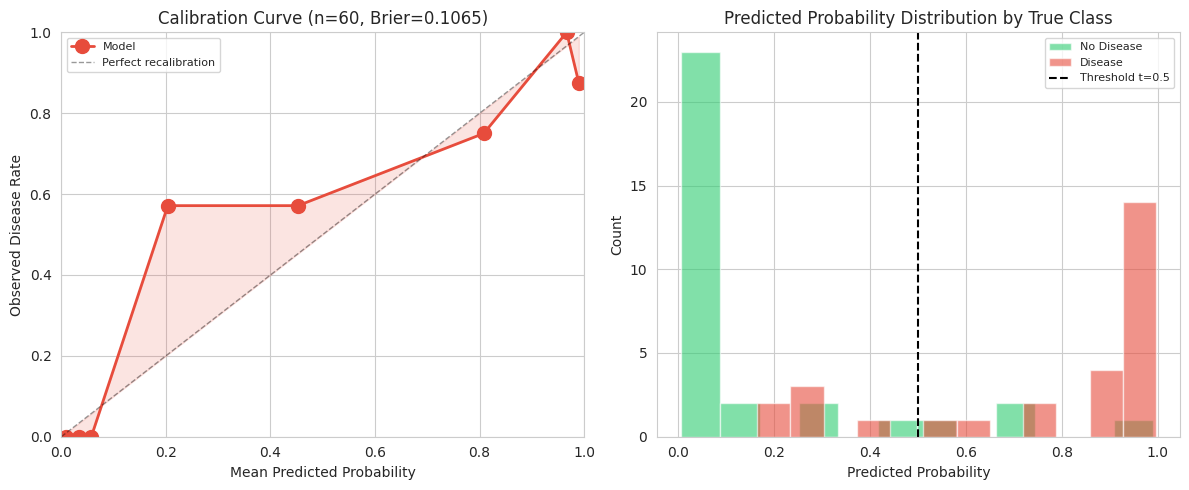

Brier score: 0.1065  (0=perfect, 0.25=random, lower=better)
Calibration: reasonable for a small dataset


In [105]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(
    y_test, test_probs, n_bins=8, strategy='quantile'
)
brier = brier_score_loss(y_test, test_probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Calibration curve ---
ax1.plot(prob_pred, prob_true, 'o-', color='#e74c3c', lw=2, ms=10, label='Model')
ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Perfect recalibration')
ax1.fill_between(prob_pred, prob_pred, prob_true, alpha=0.15, color='#e74c3c')
ax1.set_xlabel('Mean Predicted Probability'); ax1.set_ylabel('Observed Disease Rate')
ax1.set_title(f'Calibration Curve (n=60, Brier={brier:.4f})')
ax1.legend(fontsize=8); ax1.set_xlim([0, 1]); ax1.set_ylim([0, 1])

# --- Histogram: predicted prob by true class ---
for label, color, name in [(0, '#2ecc71', 'No Disease'), (1, '#e74c3c', 'Disease')]:
    ax2.hist(test_probs[y_test.values == label], bins=12, alpha=0.6,
             color=color, label=name, edgecolor='white')
ax2.axvline(THRESHOLD, color='black', ls='--', lw=1.5, label=f'Threshold t={THRESHOLD}')
ax2.set_xlabel('Predicted Probability'); ax2.set_ylabel('Count')
ax2.set_title('Predicted Probability Distribution by True Class')
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

# --- Summary ---
print(f'Brier score: {brier:.4f}  (0=perfect, 0.25=random, lower=better)')
# Check over/under-confidence
if brier < 0.15:
    print('Calibration: reasonable for a small dataset')
elif brier < 0.20:
    print('Calibration: moderate — probabilities should be treated as rankings, not exact probabilities')
else:
    print('Calibration: poor — recalibrate with Platt scaling before using probabilities clinically')